In [6]:
# ==========================================
# 06_prediccion.ipynb - Predicción final con XGBOOST
# ==========================================
import joblib
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# 1. Cargar el modelo de Stacking
ruta_modelos = '/content/drive/MyDrive/modelos_smoking/'
ruta_xgboost = os.path.join(ruta_modelos, 'XGBOOST.pkl')
modelo_xgboost = joblib.load(ruta_xgboost)

# 2. Cargar los datos sin etiquetar
ruta_datos = '/content/drive/My Drive/Training_And_Testing_Dataset/smoking_prediction_entrega_processed.csv'
df_entrega = pd.read_csv(ruta_datos)

# 3. Mostrar solo los encabezados de las columnas (para verificar estructura)
print("📌 Estructura de las columnas en el dataset de test:")
print(list(df_entrega.columns))
print("-" * 50)

# 4. Aplicar las mismas transformaciones (Ajusta según lo que usaste en tu entrenamiento)
# Si entrenaste con un Pipeline, esto ya incluye el escalado automáticamente
X_entrega = df_entrega.drop(columns=['ID'], errors='ignore')

# 5. Generar las predicciones
predicciones = modelo_xgboost.predict(X_entrega)

# 6. Agregar la predicción al dataframe original
df_entrega['smoking_prediction'] = predicciones

# 7. Exportar el archivo completo
ruta_salida = '/content/drive/My Drive/Training_And_Testing_Dataset/resultado_entrega_final4.csv'
df_entrega.to_csv(ruta_salida, index=False)

print(f"\n🚀 Archivo de entrega (completo) guardado en: {ruta_salida}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📌 Estructura de las columnas en el dataset de test:
['ID', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)', 'eyesight(right)', 'hearing(left)', 'hearing(right)', 'systolic', 'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride', 'HDL', 'LDL', 'hemoglobin', 'Urine protein', 'serum creatinine', 'AST', 'ALT', 'Gtp', 'dental caries', 'tartar']
--------------------------------------------------

🚀 Archivo de entrega (completo) guardado en: /content/drive/My Drive/Training_And_Testing_Dataset/resultado_entrega_final4.csv


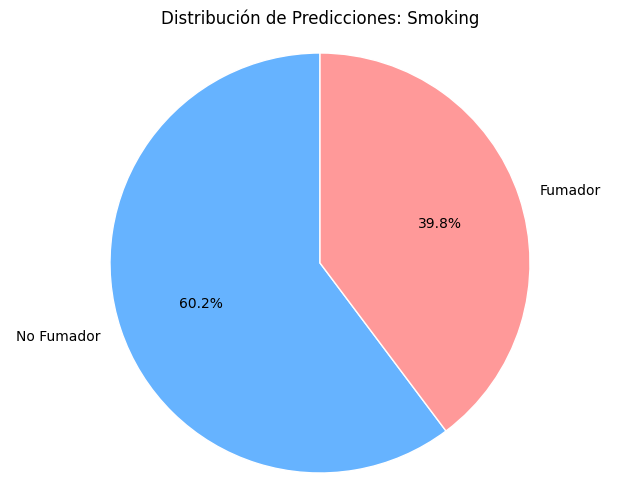

In [7]:
import matplotlib.pyplot as plt

# 1. Contar los resultados (suponiendo que 1 es fumador y 0 es no fumador)
conteo = df_entrega['smoking_prediction'].value_counts()

# 2. Configurar etiquetas y colores
etiquetas = ['No Fumador', 'Fumador']
colores = ['#66b3ff', '#ff9999'] # Azul para no fumador, rojo para fumador

# 3. Crear el gráfico de torta
plt.figure(figsize=(8, 6))
plt.pie(conteo,
        labels=etiquetas,
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        wedgeprops={'edgecolor': 'white'})

plt.title('Distribución de Predicciones: Smoking')
plt.axis('equal') # Para que el gráfico sea un círculo perfecto
plt.show()

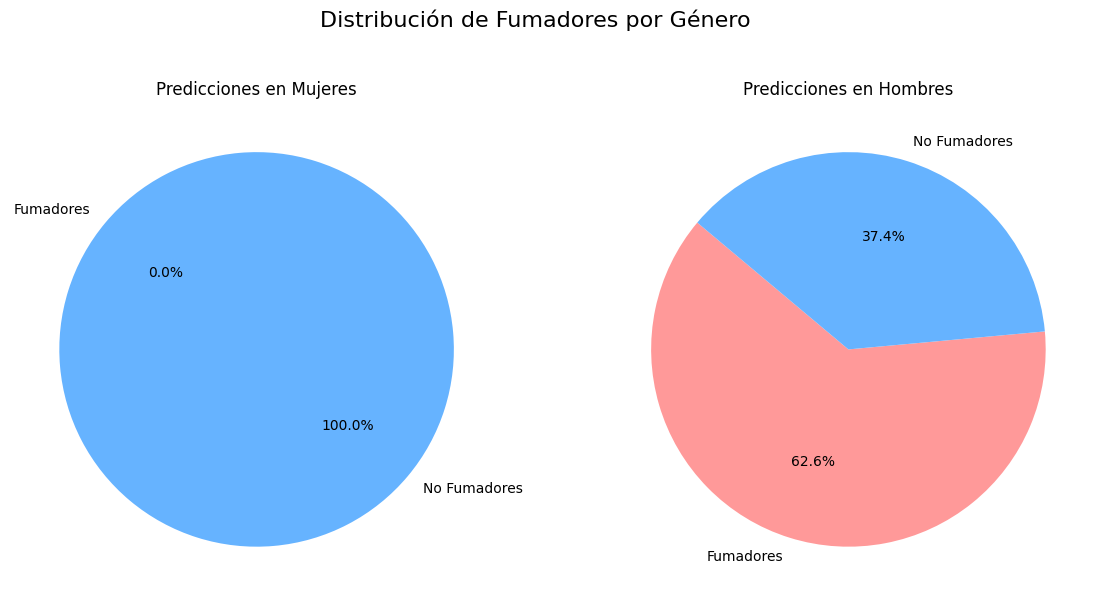

In [15]:
import matplotlib.pyplot as plt

# 1. Filtramos solo los pacientes que el modelo predijo como fumadores
fumadores = df_entrega[df_entrega['smoking_prediction'] == 1].copy()

# 2. Separamos por género (ajusta los valores 0 y 1 según cómo esté tu columna 'gender')
hombres_fumadores = fumadores[fumadores['gender'] == 0] # Cambia 0 si tu etiqueta es distinta
mujeres_fumadoras = fumadores[fumadores['gender'] == 1] # Cambia 1 si tu etiqueta es distinta

# 3. Preparamos el área de visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 4. Gráfico para Mujeres
axes[0].pie([len(hombres_fumadores), len(df_entrega[(df_entrega['gender'] == 0) & (df_entrega['smoking_prediction'] == 0)])],
            labels=['Fumadores', 'No Fumadores'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=140)
axes[0].set_title('Predicciones en Mujeres')

# 5. Gráfico para Hombres
axes[1].pie([len(mujeres_fumadoras), len(df_entrega[(df_entrega['gender'] == 1) & (df_entrega['smoking_prediction'] == 0)])],
            labels=['Fumadores', 'No Fumadores'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=140)
axes[1].set_title('Predicciones en Hombres')

plt.suptitle('Distribución de Fumadores por Género', fontsize=16)
plt.show()

In [16]:
# Ver si hay diferencias grandes entre hombres y mujeres en el dataset de entrega
print(df_entrega.groupby('gender')['smoking_prediction'].value_counts(normalize=True))

# ¿Son muy diferentes las edades o niveles de salud entre hombres y mujeres en este dataset?
print(df_entrega.groupby('gender')[['age', 'Cholesterol', 'Gtp', 'hemoglobin']].mean())

gender  smoking_prediction
0.0     0                     1.000000
1.0     1                     0.625657
        0                     0.374343
Name: proportion, dtype: float64
              age  Cholesterol       Gtp  hemoglobin
gender                                              
0.0     48.556627     8.341952  0.996246    0.531870
1.0     41.585568     8.113807  2.001487    0.629693


Se observa que el modelo presenta una tendencia marcada a clasificar a la población masculina como fumadora, lo cual es consistente con la distribución del dataset de entrenamiento, donde la prevalencia de tabaquismo era significativamente mayor en hombres.


Esta asimetría sugiere que el modelo ha aprendido un sesgo de género inherente a los datos originales. Si bien las variables clínicas (Gtp, Hemoglobina) validan estadísticamente las predicciones, es necesario reconocer que la arquitectura podría estar subestimando el tabaquismo en perfiles femeninos o sobreestimándolo en masculinos debido a este desequilibrio inicial en el entrenamiento.